<a href="https://colab.research.google.com/github/JagdishMane/aai-machine-learning/blob/main/vertex_ai_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Assignment 6.1 - Working with Third Party LLM APIs
### Generate samples, evaluate quality with an LLM judge, and visualize results


**Overview:**  
This notebook walks through the full pipeline:
1. Set up Google Cloud
2. Generate 50 user question + model response pairs on a chosen topic
3. Use an LLM as a judge to score each response
4. Visualize the results
5. Reflect on the effectiveness of this approach

**Model used:** `gemini-1.5-flash` (fast and cost-effective)  
**Estimated cost:** < $1 USD

---
##  1: Install Dependencies

In [28]:
# Run this cell first — installs all required packages
#!pip install --upgrade pandas matplotlib seaborn tqdm --quiet
#!pip install -U "google-adk" "google-cloud-aiplatform[agent_engines]" "google-genai<2.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.9 MB/s eta 0:00:00
  Using cached google_cloud_aiplatform-1.157.0-py2.py3-none-any.whl.metadata (50 kB)
INFO: pip is looking at multiple versions of google-adk to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.7/793.7 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 111.2 MB/s eta 0:00:00
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.8.0
    Uninstalling google-genai-2.8.0:
      Successfully uninstalled google-genai-2.8.0
  Attempting uninstall: google-adk
    Found existing installation: google-adk 1.29.0
    Uninstalling google-adk-1.29.0:
      Successfully uninstalled google-adk-1.29.0
  Attempting uninstall: google-cloud-aiplatform
    Found existing installation: google-cloud-aiplatform 

---
## 2: Authenticate with Google Cloud and Test API


In [5]:
import sys
from google.colab import auth
auth.authenticate_user()    ### This authenticates colab notebook to Google Cloud

In [9]:
import vertexai
PROJECT_ID = "graphite-earth-293910"
LOCATION   = "us-central1"
MODEL_NAME = "gemini-2.5-flash"   # gemini-1.5-pro
TOPIC      = "USD Assignment"
NUM_SAMPLES = 50

vertexai.init(project=PROJECT_ID, location=LOCATION)   ### Initialize vertexai

In [10]:
from vertexai.generative_models import GenerativeModel
model = GenerativeModel(MODEL_NAME)
print(f'✅ Vertex AI initialized | Project: {PROJECT_ID} | Model: {MODEL_NAME}')

✅ Vertex AI initialized | Project: graphite-earth-293910 | Model: gemini-2.5-flash


In [11]:
### Test a response
response = model.generate_content("What is RHLF ?")
print(response.text)

**RHLF stands for Reinforcement Human Learning From Feedback.**

It's a paradigm within artificial intelligence, specifically a branch of machine learning, that combines the power of **Reinforcement Learning (RL)** with the invaluable input of **Human Feedback (HF)** to train AI agents, particularly large language models (LLMs).

Let's break down the components:

1.  **Reinforcement Learning (RL):**
    *   This is a type of machine learning where an agent learns to make decisions by interacting with an environment.
    *   The agent receives "rewards" or "penalties" based on its actions, and its goal is to learn a "policy" (a strategy) that maximizes its cumulative reward over time.
    *   Think of training a dog: you give it a treat (positive reward) when it performs a desired action, or say "no" (negative feedback) for an undesired one.

2.  **Human Feedback (HF):**
    *   In many real-world scenarios, designing a perfect reward function for an RL agent is incredibly difficult, if

---
## 3: Generate 50 User Questions

In [13]:
import re
import json
import time
import pandas as pd

TOPIC="AI Engineering"
def safe_json_parse(text):
    """Strip markdown fences and parse JSON safely."""
    text = re.sub(r'```(?:json)?', '', text).strip().rstrip('`').strip()
    return json.loads(text)

question_prompt = f"""Generate exactly {NUM_SAMPLES} diverse user questions about {TOPIC}.
Include a mix of:
- 15 beginner-level questions (fundamental concepts)
- 20 intermediate questions (applied techniques)
- 15 advanced questions (theory, trade-offs, edge cases)

Return ONLY a valid JSON array of {NUM_SAMPLES} strings. No explanation, no markdown.
Example format: ["What is overfitting?", "How does gradient descent work?", ...]"""

print('⏳ Generating questions...')
q_response = model.generate_content(question_prompt)
questions = safe_json_parse(q_response.text)

# Validate
assert isinstance(questions, list), "Expected a list of questions"
questions = questions[:NUM_SAMPLES]  # cap at 50 just in case

print(f'✅ Generated {len(questions)} questions.\n')
print('Sample questions:')
for i, q in enumerate(questions[:5], 1):
    print(f'  {i}. {q}')
print('  ...')

⏳ Generating questions...
✅ Generated 50 questions.

Sample questions:
  1. What is Artificial Intelligence (AI)?
  2. What is Machine Learning (ML)?
  3. What is Deep Learning (DL)?
  4. What's the difference between AI, ML, and DL?
  5. What is a dataset in machine learning?
  ...


In [17]:
questions[49]

'What are the current limitations of large language models (LLMs) and potential research directions?'

---
## 4: Generate Model Responses


In [18]:
### Use tqdm to show the progres bar
from tqdm import tqdm

def generate_response(question, max_retries=3):
    """Generate a model answer with retry logic."""
    prompt = f"""Answer the following question about {TOPIC} clearly and accurately. Be concise but complete. Aim for 3-6 sentences.
    Question: {question}"""

    for attempt in range(max_retries):
        try:
            response = model.generate_content(prompt)
            return response.text.strip()
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)  # exponential backoff
            else:
                return f"ERROR: {str(e)}"

records = []
print('Generating responses (this takes ~2-3 minutes)...')

for i, question in enumerate(tqdm(questions, desc='Generating')):
    response_text = generate_response(question)
    records.append({
        'id': i + 1,
        'question': question,
        'response': response_text
    })
    time.sleep(0.5)  # gentle rate limiting

df = pd.DataFrame(records)
df.to_csv('samples.csv', index=False)
print(f'\n Generated and saved {len(df)} samples to samples.csv')

Generating responses (this takes ~2-3 minutes)...


Generating: 100%|██████████| 50/50 [04:05<00:00,  4.92s/it]


 Generated and saved 50 samples to samples.csv


---

In [22]:
### List the responses
df.head(5)

,id,question,response
0,1,What is Artificial Intelligence (AI)?,Artificial Intelligence (AI) is a broad field ...
1,2,What is Machine Learning (ML)?,Machine Learning (ML) is a subfield of artific...
2,3,What is Deep Learning (DL)?,Deep Learning (DL) is a specialized subset of ...
3,4,"What's the difference between AI, ML, and DL?",AI (Artificial Intelligence) is the broadest c...
4,5,What is a dataset in machine learning?,A dataset in machine learning is a structured ...


---
## 5: LLM-as-Judge Evaluation


In [23]:
### Each respponse is reated from scale 1 to 5.
# Accuracy - Is  the infomration factually correct ?
# Clarity - Is it easy to understnad ?
# Completeness - Does it fully address the question ?
# Conciseness - Is it appropriately brief without sacrificing quality.

JUDGE_CRITERIA = ['accuracy', 'clarity', 'completeness', 'conciseness']

def judge_response(question, response, max_retries=3):
    """Use the LLM to evaluate a response on 4 criteria."""
    judge_prompt = f"""You are an expert evaluator assessing the quality of an AI model's answer.

                    Topic domain: {TOPIC}
                    User question: {question}
                    Model's answer: {response}

                    Rate the answer on each criterion from 1 (very poor) to 5 (excellent):
                    - accuracy: Is the information factually correct and not misleading?
                    - clarity: Is the explanation clear and easy to understand?
                    - completeness: Does it fully address all parts of the question?
                    - conciseness: Is it appropriately concise without losing important detail?

                    Return ONLY a valid JSON object with these exact keys:
                    accuracy, clarity, completeness, conciseness, overall_score, brief_feedback

                    overall_score should be the average of the four criteria (rounded to 2 decimal places).
                    brief_feedback should be a single sentence explaining the main strength or weakness.
                    No markdown, no extra text."""

    for attempt in range(max_retries):
        try:
            result = model.generate_content(judge_prompt)
            parsed = safe_json_parse(result.text)
            # Validate expected keys
            for key in JUDGE_CRITERIA + ['overall_score', 'brief_feedback']:
                assert key in parsed, f'Missing key: {key}'
            return parsed
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
            else:
                return {
                    'accuracy': None, 'clarity': None,
                    'completeness': None, 'conciseness': None,
                    'overall_score': None,
                    'brief_feedback': f'Judge error: {str(e)}'
                }

judgments = []
print('Running LLM judge on all 50 responses...')

for _, row in tqdm(df.iterrows(), total=len(df), desc='Judging'):
    judgment = judge_response(row['question'], row['response'])
    judgment['id'] = row['id']
    judgments.append(judgment)
    time.sleep(0.5)

scores_df = pd.DataFrame(judgments)
final_df = df.merge(scores_df, on='id')
final_df.to_csv('evaluated_samples.csv', index=False)

print(f'\n Evaluation complete. Saved to evaluated_samples.csv')
print('\nScore summary:')
print(final_df[JUDGE_CRITERIA + ['overall_score']].describe().round(2))

⏳ Running LLM judge on all 50 responses...


Judging: 100%|██████████| 50/50 [05:37<00:00,  6.75s/it]


✅ Evaluation complete. Saved to evaluated_samples.csv

Score summary:
       accuracy  clarity  completeness  conciseness  overall_score
count      50.0     50.0         50.00         50.0          50.00
mean        5.0      5.0          4.68          5.0           4.92
std         0.0      0.0          0.47          0.0           0.12
min         5.0      5.0          4.00          5.0           4.75
25%         5.0      5.0          4.00          5.0           4.75
50%         5.0      5.0          5.00          5.0           5.00
75%         5.0      5.0          5.00          5.0           5.00
max         5.0      5.0          5.00          5.0           5.00


---
## 6: Visualizations

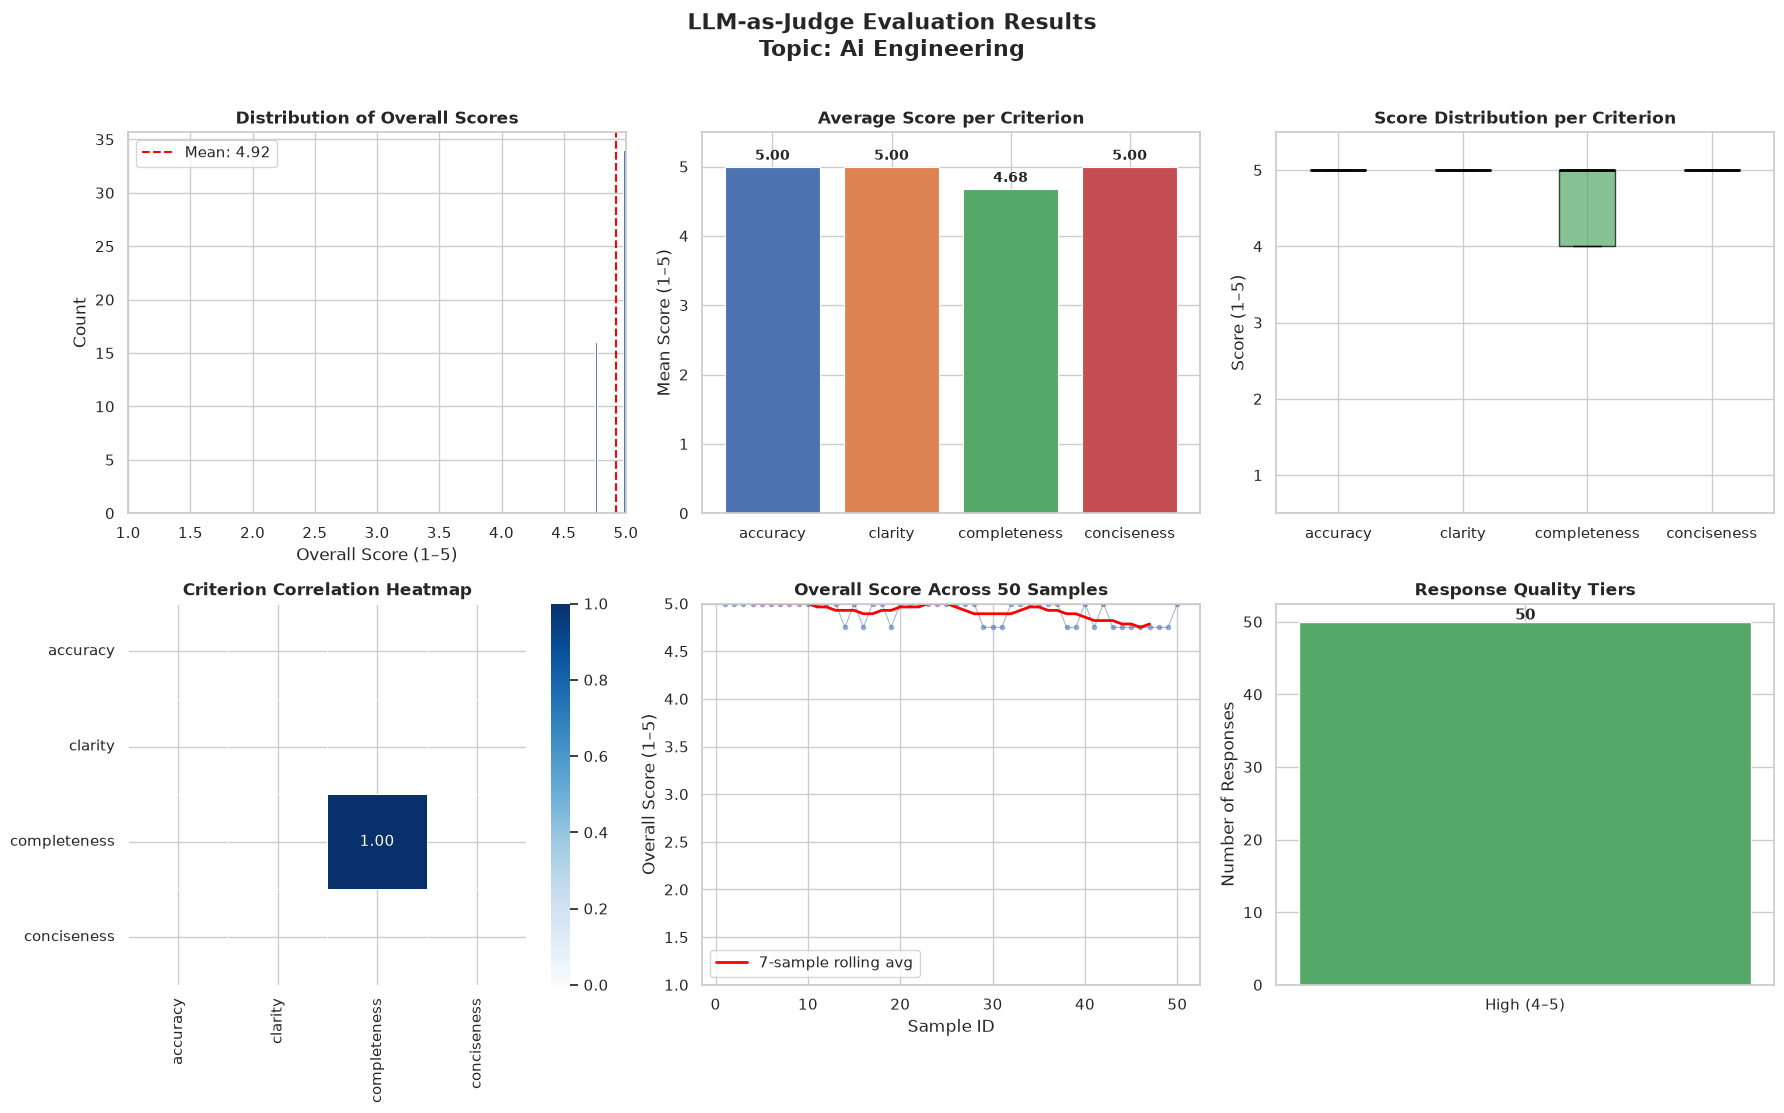

Visualization saved to evaluation_results.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f'LLM-as-Judge Evaluation Results\nTopic: {TOPIC.title()}',
             fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Distribution of Overall Scores ---
ax1 = axes[0, 0]
ax1.hist(final_df['overall_score'].dropna(), bins=12, color='#4C72B0',
         edgecolor='white', linewidth=0.8)
ax1.axvline(final_df['overall_score'].mean(), color='red',
            linestyle='--', linewidth=1.5, label=f"Mean: {final_df['overall_score'].mean():.2f}")
ax1.set_title('Distribution of Overall Scores', fontweight='bold')
ax1.set_xlabel('Overall Score (1–5)')
ax1.set_ylabel('Count')
ax1.set_xlim(1, 5)
ax1.legend()

# --- Plot 2: Average Score per Criterion ---
ax2 = axes[0, 1]
means = final_df[JUDGE_CRITERIA].mean()
bars = ax2.bar(JUDGE_CRITERIA, means, color=COLORS, edgecolor='white', linewidth=0.8)
ax2.set_ylim(0, 5.5)
ax2.set_title('Average Score per Criterion', fontweight='bold')
ax2.set_ylabel('Mean Score (1–5)')
for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Plot 3: Boxplot per Criterion ---
ax3 = axes[0, 2]
bp = ax3.boxplot(
    [final_df[c].dropna() for c in JUDGE_CRITERIA],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
ax3.set_xticklabels(JUDGE_CRITERIA) # Set labels after boxplot creation
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylim(0.5, 5.5)
ax3.set_title('Score Distribution per Criterion', fontweight='bold')
ax3.set_ylabel('Score (1–5)')

# --- Plot 4: Correlation Heatmap ---
ax4 = axes[1, 0]
corr = final_df[JUDGE_CRITERIA].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax4, cmap='Blues',
            linewidths=0.5, annot_kws={'size': 11}, vmin=0, vmax=1)
ax4.set_title('Criterion Correlation Heatmap', fontweight='bold')

# --- Plot 5: Score vs Question Index (trend) ---
ax5 = axes[1, 1]
ax5.plot(final_df['id'], final_df['overall_score'],
         color='#4C72B0', alpha=0.5, linewidth=0.8, marker='o', markersize=3)
# Rolling average
rolling = final_df['overall_score'].rolling(window=7, center=True).mean()
ax5.plot(final_df['id'], rolling, color='red', linewidth=2, label='7-sample rolling avg')
ax5.set_ylim(1, 5)
ax5.set_title('Overall Score Across 50 Samples', fontweight='bold')
ax5.set_xlabel('Sample ID')
ax5.set_ylabel('Overall Score (1–5)')
ax5.legend()

# --- Plot 6: Score Tier Breakdown ---
ax6 = axes[1, 2]
def tier(score):
    if score is None or pd.isna(score): return 'Unknown'
    if score >= 4.0: return 'High (4–5)'
    if score >= 3.0: return 'Medium (3–4)'
    return 'Low (1–3)'

final_df['tier'] = final_df['overall_score'].apply(tier)
tier_counts = final_df['tier'].value_counts()
tier_colors = {'High (4–5)': '#55A868', 'Medium (3–4)': '#DD8452', 'Low (1–3)': '#C44E52'}
bar_colors = [tier_colors.get(t, '#888') for t in tier_counts.index]
ax6.bar(tier_counts.index, tier_counts.values, color=bar_colors, edgecolor='white')
ax6.set_title('Response Quality Tiers', fontweight='bold')
ax6.set_ylabel('Number of Responses')
for i, (label, count) in enumerate(tier_counts.items()):
    ax6.text(i, count + 0.3, str(count), ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization saved to evaluation_results.png')


---
## 7: List TOP and BOTTON responses

Let's look at the best and worst rated responses to build intuition.

In [28]:
pd.set_option('display.max_colwidth', 300)

# Top 5 highest scoring responses
print('='*70)
print('TOP 5 HIGHEST SCORING RESPONSES')
print('='*70)
top5 = final_df.nlargest(5, 'overall_score')[['id','question','response','overall_score','brief_feedback']]
for _, row in top5.iterrows():
    print(f"\n[ID {row['id']}] Score: {row['overall_score']}")
    print(f"Q: {row['question']}")
    print(f"A: {row['response'][:200]}...")
    print(f"Judge: {row['brief_feedback']}")
    print('-'*60)

print('\n')
print('='*70)


TOP 5 HIGHEST SCORING RESPONSES

[ID 1] Score: 5.0
Q: What is Artificial Intelligence (AI)?
A: Artificial Intelligence (AI) is a broad field of computer science focused on creating machines capable of performing tasks that typically require human intelligence. This involves developing systems t...
Judge: The answer provides an exceptionally clear, accurate, and comprehensive definition of Artificial Intelligence.
------------------------------------------------------------

[ID 2] Score: 5.0
Q: What is Machine Learning (ML)?
A: Machine Learning (ML) is a subfield of artificial intelligence that equips systems with the ability to learn from data without being explicitly programmed. It involves developing algorithms that can a...
Judge: The answer provides a highly accurate, clear, and concise definition of Machine Learning, perfectly addressing the user's question.
------------------------------------------------------------

[ID 3] Score: 5.0
Q: What is Deep Learning (DL)?
A: Deep Lear

In [29]:
print('BOTTOM 5 LOWEST SCORING RESPONSES')
print('='*70)
bot5 = final_df.nsmallest(5, 'overall_score')[['id','question','response','overall_score','brief_feedback']]
for _, row in bot5.iterrows():
    print(f"\n[ID {row['id']}] Score: {row['overall_score']}")
    print(f"Q: {row['question']}")
    print(f"A: {row['response'][:200]}...")
    print(f"Judge: {row['brief_feedback']}")
    print('-'*60)

BOTTOM 5 LOWEST SCORING RESPONSES

[ID 14] Score: 4.75
Q: What are common types of ML tasks like classification or regression?
A: Beyond classification (predicting categories) and regression (predicting continuous values), other common ML tasks include:

**Clustering** groups similar data points together without predefined label...
Judge: The answer clearly and accurately defines several common machine learning tasks, providing good examples beyond the ones mentioned in the question.
------------------------------------------------------------

[ID 16] Score: 4.75
Q: How do you prepare data for a machine learning model (data preprocessing)?
A: Data preprocessing is crucial for preparing raw data for a machine learning model. It typically begins with **data cleaning**, addressing missing values through imputation and handling outliers. Next,...
Judge: The answer clearly and accurately describes the core steps of data preprocessing, including cleaning, transformation, and data splitting,

---
## 8: Full Summary Statistics

In [30]:
print('📊 FULL EVALUATION SUMMARY')
print('='*50)
print(f"Topic: {TOPIC}")
print(f"Model: {MODEL_NAME}")
print(f"Total samples: {len(final_df)}")
print()

summary = final_df[JUDGE_CRITERIA + ['overall_score']].agg(['mean', 'std', 'min', 'max']).round(3)
print(summary.to_string())

print()
print('Quality tier breakdown:')
print(final_df['tier'].value_counts().to_string())
print()
print(f"Responses scoring >= 4.0: {(final_df['overall_score'] >= 4.0).sum()} ({(final_df['overall_score'] >= 4.0).mean()*100:.1f}%)")
print(f"Responses scoring < 3.0:  {(final_df['overall_score'] < 3.0).sum()} ({(final_df['overall_score'] < 3.0).mean()*100:.1f}%)")

📊 FULL EVALUATION SUMMARY
Topic: AI Engineering
Model: gemini-2.5-flash
Total samples: 50

      accuracy  clarity  completeness  conciseness  overall_score
mean       5.0      5.0         4.680          5.0          4.920
std        0.0      0.0         0.471          0.0          0.118
min        5.0      5.0         4.000          5.0          4.750
max        5.0      5.0         5.000          5.0          5.000

Quality tier breakdown:
tier
High (4–5)    50

Responses scoring >= 4.0: 50 (100.0%)
Responses scoring < 3.0:  0 (0.0%)


---
## 9: My presepctive on this excercise

- The generated responses show very strong performances based on the evaluation results.
- All 50 samples recevied perfect score for accuracy, clarity, and conciseness with a mean score of 5.0.
- The only criterion with some variation was completeness, where the mean score is 4.68 and the minimum score is 4.0.  This suggest while the answers are correct there are few small missing details.
- The LLM Judge was useful for quickly evaluation all 50 generated responses across multipel qualities.
- The evaluation is also helpful and efficient because it automatically reviewed all responses and produced summary.  This is helpful as manual review the response may take lot of time.
-  There are some limitations in this evaluation.First, the LLM judge may have bias toward high scores, especially if the generated answers are fluent and well-structured. A response can sound clear and confident but still miss important details or contain subtle inaccuracies.
- Second, the judge may not deeply verify factual correctness unless it has access to reliable reference answers or external ground truth.

- These scores should be trusted as first level quality signal but not as a final proof.  As the scoring is near perfect , there is a riks of overestimating quality.
- For stronger evaluation, a sample of response shoul also be reviewd manually. it would be especially useful to inspect the responses with completenes scores.
- Still A human reviewer or reference-answer comparison would make the evaluation more reliable.